# Classification

## Dataset merged
### Grouped by category

Category distribution:
2    321561
4     86397
5     45187
0     28020
3      3596
1      2164
Name: count, dtype: int64
              precision    recall  f1-score   support

      AIRCON       0.79      0.96      0.86      5554
        DOOR       0.96      0.92      0.94       439
       LIGHT       0.99      0.99      0.99     64110
      MOTION       0.96      0.98      0.97       730
        OTBR       1.00      1.00      1.00     17422
        PLUG       0.96      0.81      0.88      9130

    accuracy                           0.97     97385
   macro avg       0.94      0.94      0.94     97385
weighted avg       0.98      0.97      0.97     97385

Weighted F1-Score: 0.9749


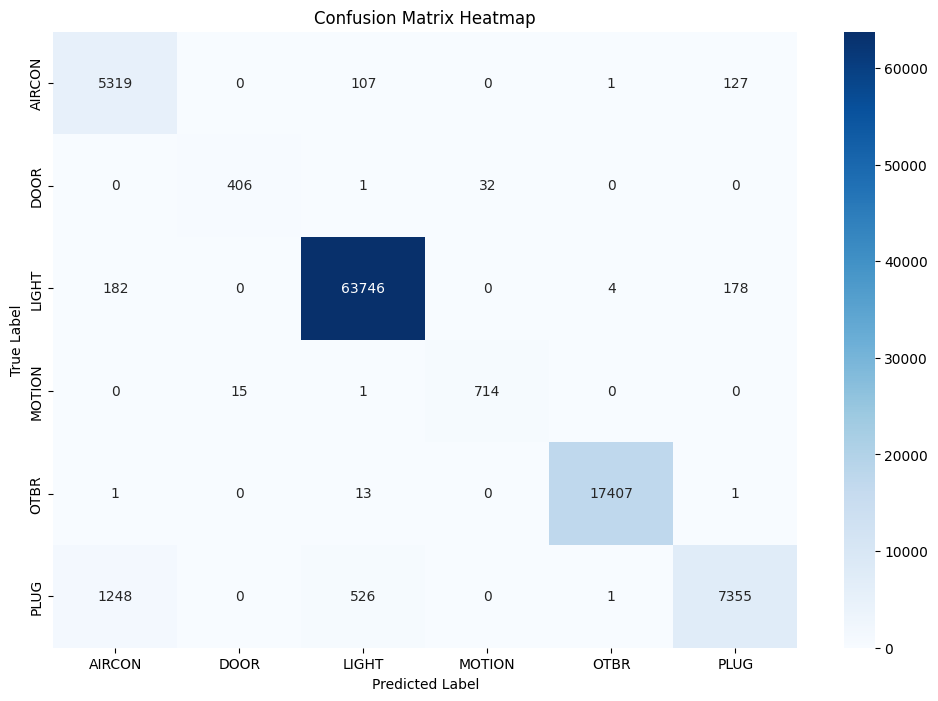

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./6-Merge-and-drop-unknown/fix_duration_5s.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### By single devices

Category distribution:
12    86397
10    85780
8     85630
9     85194
3     51496
6     23416
2     17742
4     13461
11    12614
7     10278
5      9157
1      3596
0      2164
Name: count, dtype: int64
                   precision    recall  f1-score   support

Aqara Door/Window       0.96      0.93      0.94       439
     Aqara Motion       0.96      0.98      0.97       730
    ESP Arancione       0.89      0.76      0.82      3526
      ESP Azzurro       0.98      0.95      0.96     10152
       ESP Bianco       0.84      0.94      0.88      2621
       ESP Giallo       0.76      0.87      0.81      1841
        ESP Rosso       0.88      0.87      0.87      4779
        ESP Viola       0.75      0.93      0.83      2028
    Nanoleaf 0176       0.89      0.81      0.85     17107
    Nanoleaf 1624       0.74      0.74      0.74     16958
    Nanoleaf 2248       0.73      0.78      0.75     17272
            Onvis       0.91      0.95      0.93      2510
      Raspberry 4       1.0

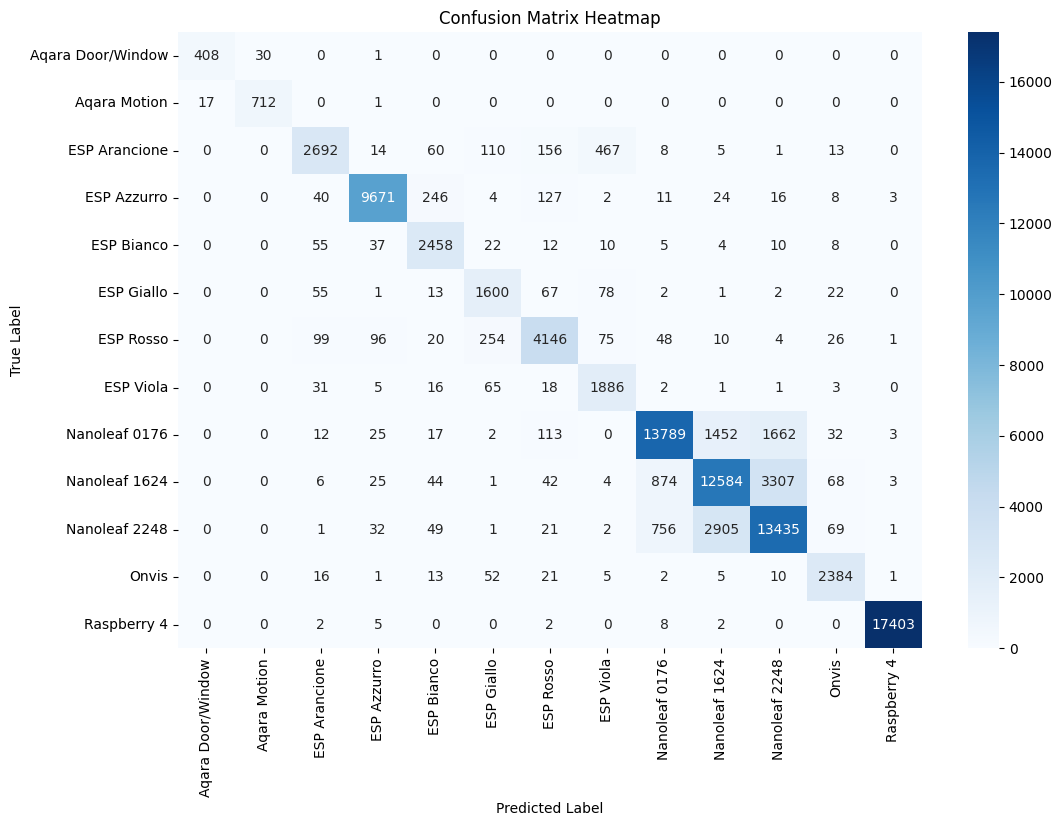

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./6-Merge-and-drop-unknown/fix_duration_5s.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A, Test B

Category distribution train set:
12    43197
10    42997
8     42824
9     42204
6     18674
4      9023
3      8333
2      7890
11     7826
7      5348
5      5183
0      1237
1      1222
Name: count, dtype: int64
Category distribution test set:
12    43200
3     43163
9     42990
8     42806
10    42783
2      9852
7      4930
11     4788
6      4742
4      4438
5      3974
1      2374
0       927
Name: count, dtype: int64
                   precision    recall  f1-score   support

Aqara Door/Window       0.42      0.60      0.49       927
     Aqara Motion       0.81      0.67      0.74      2374
    ESP Arancione       0.25      0.08      0.13      9852
      ESP Azzurro       0.70      0.13      0.22     43163
       ESP Bianco       0.10      0.02      0.04      4438
       ESP Giallo       0.00      0.00      0.00      3974
        ESP Rosso       0.00      0.00      0.00      4742
        ESP Viola       0.44      0.65      0.52      4930
    Nanoleaf 0176       0.18      0.13 

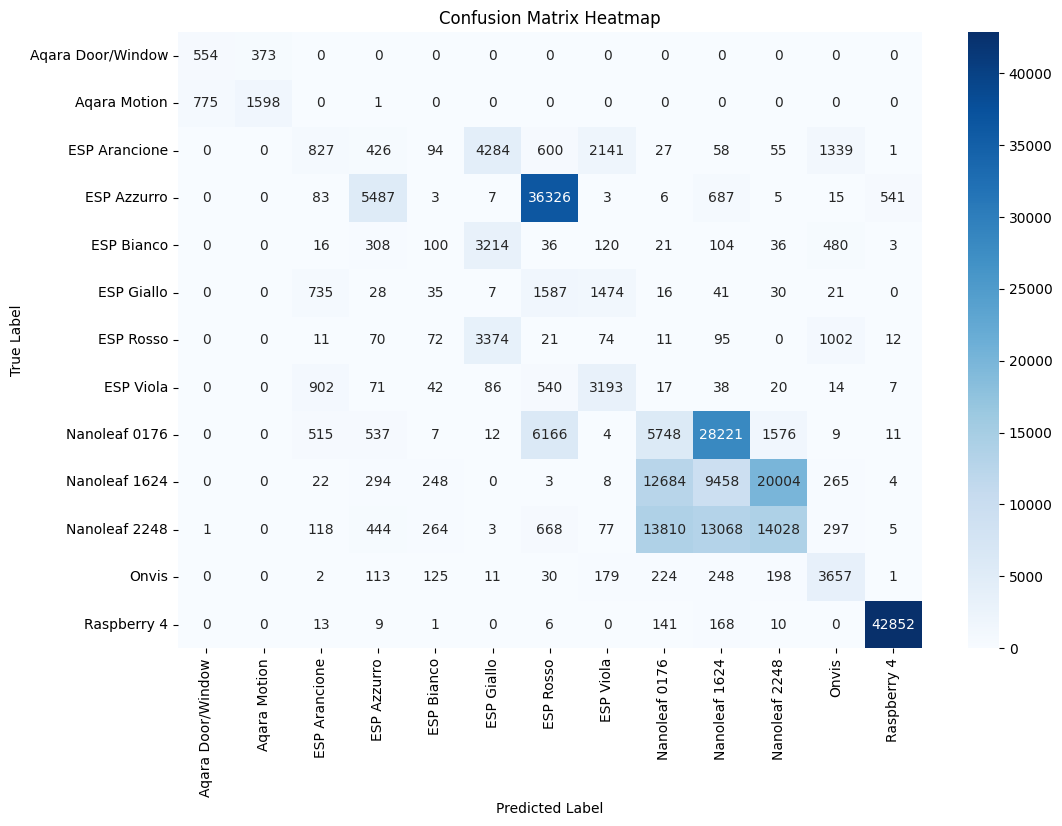

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./6-Merge-and-drop-unknown/fix_duration_5s.csv"
data = pd.read_csv(file_path)
data1 = data[data["File Name"] == "..\\Data-Long captures\\4-Sort_dataset\\Lunga 1_sort.csv"]
data2 = data[data["File Name"] == "..\\Data-Long captures\\4-Sort_dataset\\Lunga 2_sort.csv"]

X_train = data1.drop(columns=["Device Name", "Device Type","File Name"])
y_train = data1["Device Name"]

y_train = y_train.astype('category')
categories_train = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution train set:")
print(pd.Series(y_train).value_counts())

X_test = data2.drop(columns=["Device Name", "Device Type","File Name"])
y_test = data2["Device Name"]

y_test = y_test.astype('category')
categories_test = y_test.cat.categories
y_test = y_test.cat.codes

print("Category distribution test set:")
print(pd.Series(y_test).value_counts())

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories_train[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()